In [33]:
# Correction de l'affichage des résultats sans utiliser ace_tools

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger le dataset fourni
file_path = 'data/dataP/preprocessed_student_depression_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("Données chargées avec succès.")
    
    # Création du DataFrame contenant les valeurs uniques par colonne
    unique_values_list = [(col, len(df[col].unique()), df[col].unique()) for col in df.columns]

    # Conversion en DataFrame pour affichage structuré
    unique_values_df = pd.DataFrame(unique_values_list, columns=["Feature", "Nombre de Valeurs Uniques", "Valeurs Uniques"])

    # Affichage structuré des valeurs uniques par colonne
    print("Valeurs uniques par colonne :\n")
    print(unique_values_df.to_string())  # Affichage propre en format texte

except FileNotFoundError:
    print(f"Erreur : Le fichier {file_path} est introuvable. Vérifie le chemin du fichier.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")


Données chargées avec succès.
Valeurs uniques par colonne :

                                      Feature  Nombre de Valeurs Uniques                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Valeurs Uniques
0                                         Age                         34                                                                                                                                                                                                        

In [53]:
# Réexécution après réinitialisation

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Définition du chemin du fichier
file_path = 'data/Student Depression Dataset.csv'

try:
    # Chargement du dataset
    df = pd.read_csv(file_path)
    print("Données chargées avec succès.")

    # Définition de la colonne cible
    target_column = "Depression"

    # Vérification si la colonne cible existe
    if target_column not in df.columns:
        raise ValueError(f"La colonne cible '{target_column}' est absente des données.")
    print(f"Colonne cible définie : {target_column}")

    # Suppression de la colonne 'id' si elle existe
    if 'id' in df.columns:
        df.drop(['id'], axis=1, inplace=True)
        print("Colonne 'id' supprimée.")

    # Encodage de la variable 'Gender' en 0 et 1
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
        print("Encodage de 'Gender' en 0 et 1 effectué.")

    # Encodage des variables ordinales avec LabelEncoder
    enc = LabelEncoder()
    ordinal_columns = ['City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Financial Stress']
    
    for col in ordinal_columns:
        if col in df.columns:
            df[col] = enc.fit_transform(df[col].astype(str))  # Conversion en str pour éviter les erreurs
            print(f"Encodage de '{col}' effectué.")

    # Encodage des variables binaires en 0 et 1
    binary_columns = ['Family History of Mental Illness', 'Have you ever had suicidal thoughts ?']
    
    for col in binary_columns:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0})
            print(f"Encodage de '{col}' en 0 et 1 effectué.")

    # Définition du chemin de sortie
    output_file = 'data/preprocessed_student_depression_dataset.csv'
    
    # Sauvegarde du dataset prétraité
    df.to_csv(output_file, index=False)
    print(f"\nNouveau fichier CSV enregistré sous '{output_file}'.")

    # Affichage des premières lignes du dataset prétraité
    import ace_tools as tools
    tools.display_dataframe_to_user(name="Dataset Prétraité", dataframe=df)

except FileNotFoundError:
    print(f"Erreur : Le fichier '{file_path}' est introuvable. Vérifie le chemin du fichier.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")


Données chargées avec succès.
Colonne cible définie : Depression
Colonne 'id' supprimée.
Encodage de 'Gender' en 0 et 1 effectué.
Encodage de 'City' effectué.
Encodage de 'Profession' effectué.
Encodage de 'Sleep Duration' effectué.
Encodage de 'Dietary Habits' effectué.
Encodage de 'Degree' effectué.
Encodage de 'Financial Stress' effectué.
Encodage de 'Family History of Mental Illness' en 0 et 1 effectué.
Encodage de 'Have you ever had suicidal thoughts ?' en 0 et 1 effectué.

Nouveau fichier CSV enregistré sous 'data/preprocessed_student_depression_dataset.csv'.
Une erreur est survenue : No module named 'ace_tools'


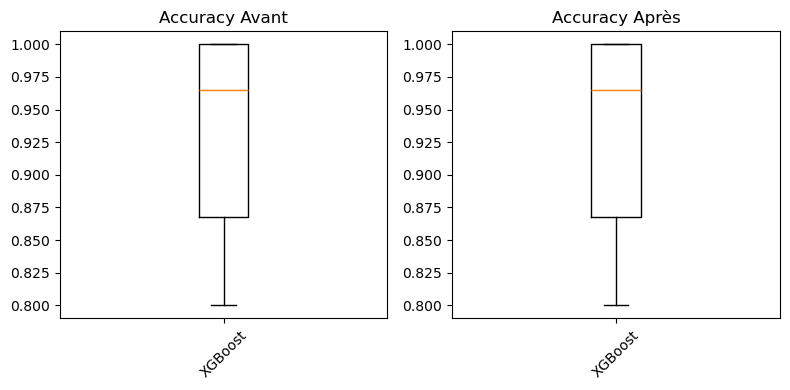

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# Définition du chemin du fichier
file_path = "resultats_iterations.xlsx"

# Charger la feuille de calcul dans un DataFrame
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Création de boxplots simplifiés en noir et blanc
plt.figure(figsize=(8, 4))

# Boxplot pour Accuracy Avant
plt.subplot(1, 2, 1)
plt.boxplot([df['Accuracy Avant'][df['Modèle'] == model] for model in df['Modèle'].unique()])
plt.xticks(range(1, len(df['Modèle'].unique()) + 1), df['Modèle'].unique(), rotation=45)
plt.title("Accuracy Avant")

# Boxplot pour Accuracy Après
plt.subplot(1, 2, 2)
plt.boxplot([df['Accuracy Après'][df['Modèle'] == model] for model in df['Modèle'].unique()])
plt.xticks(range(1, len(df['Modèle'].unique()) + 1), df['Modèle'].unique(), rotation=45)
plt.title("Accuracy Après")

# Ajustement et affichage
plt.tight_layout()
plt.show()


In [19]:
# Recharger les bibliothèques nécessaires après la réinitialisation
import numpy as np
import pandas as pd
from sklearn import datasets
from scipy.spatial.distance import cdist

# Fonction pour charger le dataset Iris
def load_iris_dataset():
    """Charge le dataset Iris sous forme de DataFrame."""
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['species'] = iris.target  # Ajout des labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)
    return df

# Fonction pour calculer la distance de Manhattan
def manhattan_distance(X, Y):
    """Calcule la distance de Manhattan entre les matrices X et Y."""
    return cdist(X, Y, metric='cityblock')

# Fonction de Diversified Distance-Based Sampling avec pourcentage équilibré
def diversified_distance_based_sampling_percentage(df, percentage_per_class):
    """
    Applique Diversified Distance-Based Sampling (DDBS) en sélectionnant un pourcentage équilibré d'échantillons par classe.

    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe (ex: 0.2 pour 20%).

    Retourne :
    - DataFrame échantillonné
    """
    np.random.seed()  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    samples_per_class = {cls: max(1, int(percentage_per_class * count)) for cls, count in zip(unique_classes, class_counts)}

    #print(samples_per_class)

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    print(class_selected_counts)

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner jusqu'à atteindre le nombre défini par classe
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Calculer la distance de Manhattan entre les échantillons sélectionnés et les candidats restants
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = manhattan_distance(sampled_features, candidate_features)

        # Sélectionner le candidat le plus éloigné qui appartient à une classe sous-représentée
        min_distances = distances.min(axis=0)
        best_candidate = None
        best_candidate_class = None
        max_distance = -1

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if class_selected_counts[candidate_class] < samples_per_class[candidate_class]:
                if min_distances[idx] > max_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    max_distance = min_distances[idx]

        # Ajouter le candidat à l'échantillon
        if best_candidate is not None:
            sampled_indices.append(best_candidate)
            candidate_indices.remove(best_candidate)
            class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné

# Charger le dataset Iris
df_iris = load_iris_dataset()

# Définir le pourcentage d'échantillons à sélectionner par classe (20% par classe)
percentage_per_class = 0.2

# Appliquer la version DDBS avec un critère de pourcentage équilibré
sampled_iris_percentage = diversified_distance_based_sampling_percentage(df_iris, percentage_per_class)

# Afficher le dataset échantillonné
print("\nDataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :")
print(sampled_iris_percentage)


{0: 0, 1: 0, 2: 0}

Dataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
43                 5.0               3.5                1.6               0.6   
84                 5.4               3.0                4.5               1.5   
121                5.6               2.8                4.9               2.0   
117                7.7               3.8                6.7               2.2   
60                 5.0               2.0                3.5               1.0   
129                7.2               3.0                5.8               1.6   
100                6.3               3.3                6.0               2.5   
41                 4.5               2.3                1.3               0.3   
14                 5.8               4.0                1.2               0.2   
134                6.1               2.6                5.6               1.4   
141                

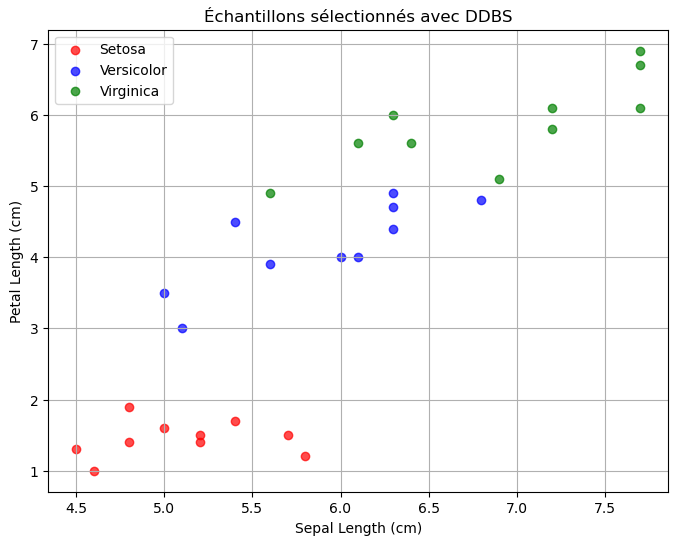

In [21]:
import matplotlib.pyplot as plt

# Extraire les caractéristiques pour le graphique
selected_features = sampled_iris_percentage.iloc[:, [0, 2]].values  # Utiliser "sepal length" et "petal length"
selected_labels = sampled_iris_percentage.iloc[:, -1].values  # Espèces sélectionnées

# Afficher les points sélectionnés sur un graphe
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
labels_map = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

for cls in np.unique(selected_labels):
    class_indices = selected_labels == cls
    plt.scatter(selected_features[class_indices, 0], selected_features[class_indices, 1],
                color=colors[int(cls)], label=labels_map[cls], alpha=0.7)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Échantillons sélectionnés avec DDBS")
plt.legend()
plt.grid(True)
plt.show()


In [85]:
# Modifier la fonction pour assurer une répartition équilibrée des classes
def diversified_distance_based_sampling_balanced(df, percentage_per_class):
    """
    Applique Diversified Distance-Based Sampling (DDBS) avec une répartition équilibrée des classes.
    
    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe.
    
    Retourne :
    - DataFrame échantillonné avec un équilibre strict des classes.
    """
    np.random.seed(42)  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe de manière équilibrée
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    min_class_size = min([int(percentage_per_class * count) for count in class_counts])  # Prendre la plus petite classe comme référence
    samples_per_class = {cls: min_class_size for cls in unique_classes}  # Équilibrer toutes les classes

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner jusqu'à atteindre le nombre défini par classe de manière équilibrée
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Vérifier si toutes les classes ont atteint leur quota
        if all(class_selected_counts[cls] >= samples_per_class[cls] for cls in unique_classes):
            break  # Arrêter si toutes les classes ont atteint le nombre requis

        # Calculer la distance de Manhattan entre les échantillons sélectionnés et les candidats restants
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = manhattan_distance(sampled_features, candidate_features)

        # Déterminer la distance maximale actuelle
        max_distance = distances.max()

        # Sélectionner une distance de manière binomiale (n = max_distance, p = 0.5)
        selected_distance = np.random.binomial(n=max_distance, p=0.5)

        # Sélectionner le candidat dont la distance est >= à la distance sélectionnée aléatoirement
        best_candidate = None
        best_candidate_class = None
        min_distances = distances.min(axis=0)  # Calculer les distances minimales pour chaque candidat

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if class_selected_counts[candidate_class] < samples_per_class[candidate_class]:
                if min_distances[idx] >= selected_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    break  # Prend le premier qui correspond et arrête la boucle

        # Si aucun candidat n'a été trouvé, prendre celui avec la distance maximale restante
        if best_candidate is None:
            best_candidate_idx = np.argmax(min_distances)
            best_candidate = candidate_indices[best_candidate_idx]
            best_candidate_class = labels[best_candidate]

        # Ajouter le candidat à l'échantillon
        sampled_indices.append(best_candidate)
        candidate_indices.remove(best_candidate)
        class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné équilibré

# Appliquer la version équilibrée du DDBS
sampled_iris_balanced = diversified_distance_based_sampling_balanced(df_iris, percentage_per_class_reduced)

# Vérifier la répartition des classes après équilibrage
num_instances_selected_balanced = sampled_iris_balanced.shape[0]
instances_per_class_balanced = sampled_iris_balanced['species'].value_counts()

# Affichage des résultats
num_instances_selected_balanced, instances_per_class_balanced


(58,
 species
 2    24
 1    19
 0    15
 Name: count, dtype: int64)

In [93]:
import numpy as np
import pandas as pd
from sklearn import datasets
from scipy.spatial.distance import cdist

# Fonction pour charger le dataset Iris
def load_iris_dataset():
    """Charge le dataset Iris sous forme de DataFrame."""
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['species'] = iris.target  # Ajout des labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)
    return df

# Fonction pour calculer la distance de Manhattan
def manhattan_distance(X, Y):
    """Calcule la distance de Manhattan entre les matrices X et Y."""
    return cdist(X, Y, metric='cityblock')

# Fonction de Diversified Distance-Based Sampling avec distribution binomiale
def diversified_distance_based_sampling_binomial(df, percentage_per_class):
    """
    Applique Diversified Distance-Based Sampling (DDBS) en sélectionnant un pourcentage équilibré d'échantillons par classe,
    avec une sélection de distance basée sur une distribution binomiale et arrêt de sélection pour les classes complètes.

    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe (ex: 0.2 pour 20%).

    Retourne :
    - DataFrame échantillonné
    """
    np.random.seed(42)  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    samples_per_class = {cls: max(1, int(percentage_per_class * count)) for cls, count in zip(unique_classes, class_counts)}

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner tant qu'au moins une classe n'a pas atteint son quota
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Filtrer les classes ayant déjà atteint leur quota
        remaining_classes = [cls for cls in unique_classes if class_selected_counts[cls] < samples_per_class[cls]]

        if not remaining_classes:
            break  # Si toutes les classes ont atteint leur quota, on arrête

        # Calculer la distance de Manhattan entre les échantillons sélectionnés et les candidats restants
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = manhattan_distance(sampled_features, candidate_features)

        # Déterminer la distance maximale actuelle
        max_distance = distances.max()

        # Sélectionner une distance de manière binomiale (n = max_distance, p = 0.5)
        selected_distance = np.random.binomial(n=max_distance, p=0.5)

        # Sélectionner le candidat dont la distance est >= à la distance sélectionnée aléatoirement
        best_candidate = None
        best_candidate_class = None
        min_distances = distances.min(axis=0)  # Calculer les distances minimales pour chaque candidat

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if candidate_class in remaining_classes:  # Ne choisir que les classes qui n'ont pas encore atteint leur quota
                if min_distances[idx] >= selected_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    break  # Prend le premier qui correspond et arrête la boucle

        # Si aucun candidat n'a été trouvé, prendre celui avec la distance maximale restante pour une classe admissible
        if best_candidate is None:
            remaining_indices = [i for i, idx in enumerate(candidate_indices) if labels[idx] in remaining_classes]
            if remaining_indices:  # Vérifier qu'il y a encore des candidats disponibles
                best_candidate_idx = remaining_indices[np.argmax(np.take(min_distances, remaining_indices))]
                best_candidate = candidate_indices[best_candidate_idx]
                best_candidate_class = labels[best_candidate]

        # Ajouter le candidat à l'échantillon
        sampled_indices.append(best_candidate)
        candidate_indices.remove(best_candidate)
        class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné

# Charger le dataset Iris
df_iris = load_iris_dataset()

# Définir le pourcentage d'échantillons à sélectionner par classe (30% par classe)
percentage_per_class = 0.2

# Appliquer la version DDBS avec sélection binomiale des distances et arrêt par classe
sampled_iris_binomial = diversified_distance_based_sampling_binomial(df_iris, percentage_per_class)

# Afficher le nombre total d'instances sélectionnées après réduction
num_instances_selected = sampled_iris_binomial.shape[0]
print(f"Nombre total d'instances sélectionnées : {num_instances_selected}")

# Afficher le nombre d'instances par classe
instances_per_class = sampled_iris_binomial['species'].value_counts()
print("\nNombre d'instances par classe :")
print(instances_per_class)

# Afficher le dataset échantillonné
print("\nDataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :")
print(sampled_iris_binomial)


Nombre total d'instances sélectionnées : 30

Nombre d'instances par classe :
species
0    10
1    10
2    10
Name: count, dtype: int64

Dataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
38                 4.4               3.0                1.3               0.2   
78                 6.0               2.9                4.5               1.5   
114                5.8               2.8                5.1               2.4   
131                7.9               3.8                6.4               2.0   
60                 5.0               2.0                3.5               1.0   
15                 5.7               4.4                1.5               0.4   
129                7.2               3.0                5.8               1.6   
118                7.7               2.6                6.9               2.3   
100                6.3               3.3                6.0      

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from scipy.spatial.distance import cdist

# Fonction pour charger le dataset Iris
def load_iris_dataset():
    """Charge le dataset Iris sous forme de DataFrame."""
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['species'] = iris.target  # Ajout des labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)
    return df

# Fonction pour calculer la distance de Manhattan
def manhattan_distance(X, Y):
    """Calcule la distance de Manhattan entre les matrices X et Y."""
    return cdist(X, Y, metric='cityblock')

# Fonction de Diversified Distance-Based Sampling avec choix de distribution
def diversified_distance_based_sampling(df, percentage_per_class, distribution_type="binomial"):
    """
    Applique Diversified Distance-Based Sampling (DDBS) en sélectionnant un pourcentage équilibré d'échantillons par classe,
    avec une sélection de distance basée sur la distribution choisie.

    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe (ex: 0.2 pour 20%).
    - distribution_type : Type de distribution ("uniform", "binomial", "geometric").

    Retourne :
    - DataFrame échantillonné
    """
    np.random.seed(42)  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    samples_per_class = {cls: max(1, int(percentage_per_class * count)) for cls, count in zip(unique_classes, class_counts)}

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner tant qu'au moins une classe n'a pas atteint son quota
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Filtrer les classes ayant déjà atteint leur quota
        remaining_classes = [cls for cls in unique_classes if class_selected_counts[cls] < samples_per_class[cls]]

        if not remaining_classes:
            break  # Si toutes les classes ont atteint leur quota, on arrête

        # Calculer la distance de Manhattan entre les échantillons sélectionnés et les candidats restants
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = manhattan_distance(sampled_features, candidate_features)

        # Déterminer la distance maximale actuelle
        max_distance = distances.max()

        # Sélectionner une distance en fonction de la distribution choisie
        if distribution_type == "uniform":
            selected_distance = np.random.randint(1, max_distance + 1)
        elif distribution_type == "binomial":
            selected_distance = np.random.binomial(n=max_distance, p=0.5)
        elif distribution_type == "geometric":
            selected_distance = min(max_distance, np.random.geometric(0.3))
        else:
            raise ValueError("Distribution non supportée. Choisissez 'uniform', 'binomial', ou 'geometric'.")

        # Sélectionner le candidat dont la distance est >= à la distance sélectionnée aléatoirement
        best_candidate = None
        best_candidate_class = None
        min_distances = distances.min(axis=0)  # Calculer les distances minimales pour chaque candidat

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if candidate_class in remaining_classes:  # Ne choisir que les classes qui n'ont pas encore atteint leur quota
                if min_distances[idx] >= selected_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    break  # Prend le premier qui correspond et arrête la boucle

        # Si aucun candidat n'a été trouvé, prendre celui avec la distance maximale restante pour une classe admissible
        if best_candidate is None:
            remaining_indices = [i for i, idx in enumerate(candidate_indices) if labels[idx] in remaining_classes]
            if remaining_indices:  # Vérifier qu'il y a encore des candidats disponibles
                best_candidate_idx = remaining_indices[np.argmax(np.take(min_distances, remaining_indices))]
                best_candidate = candidate_indices[best_candidate_idx]
                best_candidate_class = labels[best_candidate]

        # Ajouter le candidat à l'échantillon
        sampled_indices.append(best_candidate)
        candidate_indices.remove(best_candidate)
        class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné

# Charger le dataset Iris
df_iris = load_iris_dataset()

# Définir le pourcentage d'échantillons à sélectionner par classe (20% par classe)
percentage_per_class = 0.2

# Choisir la distribution de probabilité
distribution_choice = "geometric"  # Peut être "uniform", "binomial", ou "geometric"

# Appliquer la version DDBS avec la distribution choisie
sampled_iris = diversified_distance_based_sampling(df_iris, percentage_per_class, distribution_choice)

# Afficher le nombre total d'instances sélectionnées
num_instances_selected = sampled_iris.shape[0]
print(f"Nombre total d'instances sélectionnées : {num_instances_selected}")

# Afficher le nombre d'instances par classe
instances_per_class = sampled_iris['species'].value_counts()
print("\nNombre d'instances par classe :")
print(instances_per_class)

# Afficher le dataset échantillonné
print("\nDataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :")
print(sampled_iris)


Nombre total d'instances sélectionnées : 30

Nombre d'instances par classe :
species
0    10
1    10
2    10
Name: count, dtype: int64

Dataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
38                 4.4               3.0                1.3               0.2   
78                 6.0               2.9                4.5               1.5   
114                5.8               2.8                5.1               2.4   
117                7.7               3.8                6.7               2.2   
15                 5.7               4.4                1.5               0.4   
0                  5.1               3.5                1.4               0.2   
5                  5.4               3.9                1.7               0.4   
14                 5.8               4.0                1.2               0.2   
60                 5.0               2.0                3.5      

In [3]:
import numpy as np
import pandas as pd
from sklearn import datasets
from scipy.spatial.distance import cdist

# Fonction pour charger le dataset Iris
def load_iris_dataset():
    """Charge le dataset Iris sous forme de DataFrame."""
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['species'] = iris.target  # Ajout des labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)
    return df

# Fonction pour calculer une distance (Manhattan ou Euclidienne)
def compute_distance(X, Y, metric="manhattan"):
    """Calcule la distance entre les matrices X et Y selon la métrique choisie."""
    if metric == "manhattan":
        return cdist(X, Y, metric='cityblock')  # Distance de Manhattan
    elif metric == "euclidean":
        return cdist(X, Y, metric='euclidean')  # Distance Euclidienne
    else:
        raise ValueError("Métrique non supportée. Choisissez 'manhattan' ou 'euclidean'.")

# Fonction de Diversified Distance-Based Sampling avec choix de distance et distribution
def diversified_distance_based_sampling(df, percentage_per_class, distance_metric="manhattan", distribution_type="binomial"):
    """
    Applique Diversified Distance-Based Sampling (DDBS) en sélectionnant un pourcentage équilibré d'échantillons par classe,
    avec un choix de métrique de distance et de distribution.

    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe (ex: 0.2 pour 20%).
    - distance_metric : Type de distance à utiliser ("manhattan" ou "euclidean").
    - distribution_type : Type de distribution ("uniform", "binomial", "geometric").

    Retourne :
    - DataFrame échantillonné
    """
    np.random.seed(42)  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    samples_per_class = {cls: max(1, int(percentage_per_class * count)) for cls, count in zip(unique_classes, class_counts)}

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner tant qu'au moins une classe n'a pas atteint son quota
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Filtrer les classes ayant déjà atteint leur quota
        remaining_classes = [cls for cls in unique_classes if class_selected_counts[cls] < samples_per_class[cls]]

        if not remaining_classes:
            break  # Si toutes les classes ont atteint leur quota, on arrête

        # Calculer la distance selon la métrique choisie
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = compute_distance(sampled_features, candidate_features, metric=distance_metric)

        # Déterminer la distance maximale actuelle
        max_distance = distances.max()

        # Sélectionner une distance selon la distribution choisie
        if distribution_type == "uniform":
            selected_distance = np.random.randint(1, max_distance + 1)
        elif distribution_type == "binomial":
            selected_distance = np.random.binomial(n=max_distance, p=0.5)
        elif distribution_type == "geometric":
            selected_distance = min(max_distance, np.random.geometric(0.3))
        else:
            raise ValueError("Distribution non supportée. Choisissez 'uniform', 'binomial', ou 'geometric'.")

        # Sélectionner le candidat avec une distance minimale respectant le seuil
        best_candidate = None
        best_candidate_class = None
        min_distances = distances.min(axis=0)

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if candidate_class in remaining_classes:
                if min_distances[idx] >= selected_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    break

        # Si aucun candidat ne respecte la contrainte, prendre celui avec la distance maximale restante
        if best_candidate is None:
            remaining_indices = [i for i, idx in enumerate(candidate_indices) if labels[idx] in remaining_classes]
            if remaining_indices:
                best_candidate_idx = remaining_indices[np.argmax(np.take(min_distances, remaining_indices))]
                best_candidate = candidate_indices[best_candidate_idx]
                best_candidate_class = labels[best_candidate]

        # Ajouter le candidat à l'échantillon
        sampled_indices.append(best_candidate)
        candidate_indices.remove(best_candidate)
        class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné

# Charger le dataset Iris
df_iris = load_iris_dataset()

# Définir le pourcentage d'échantillons à sélectionner par classe (20% par classe)
percentage_per_class = 0.2

# Choisir la métrique de distance et la distribution
distance_choice = "euclidean"  # Peut être "manhattan" ou "euclidean"
distribution_choice = "geometric"  # Peut être "uniform", "binomial", ou "geometric"

# Appliquer la version DDBS avec la distance et la distribution choisies
sampled_iris = diversified_distance_based_sampling(df_iris, percentage_per_class, distance_choice, distribution_choice)

# Afficher le nombre total d'instances sélectionnées
num_instances_selected = sampled_iris.shape[0]
print(f"Nombre total d'instances sélectionnées : {num_instances_selected}")

# Afficher le nombre d'instances par classe
instances_per_class = sampled_iris['species'].value_counts()
print("\nNombre d'instances par classe :")
print(instances_per_class)

# Afficher le dataset échantillonné
print("\nDataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :")
print(sampled_iris)


Nombre total d'instances sélectionnées : 30

Nombre d'instances par classe :
species
0    10
1    10
2    10
Name: count, dtype: int64

Dataset sélectionné avec Diversified Distance-Based Sampling (DDBS) :
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
38                 4.4               3.0                1.3               0.2   
78                 6.0               2.9                4.5               1.5   
114                5.8               2.8                5.1               2.4   
131                7.9               3.8                6.4               2.0   
15                 5.7               4.4                1.5               0.4   
20                 5.4               3.4                1.7               0.2   
50                 7.0               3.2                4.7               1.4   
57                 4.9               2.4                3.3               1.0   
118                7.7               2.6                6.9      

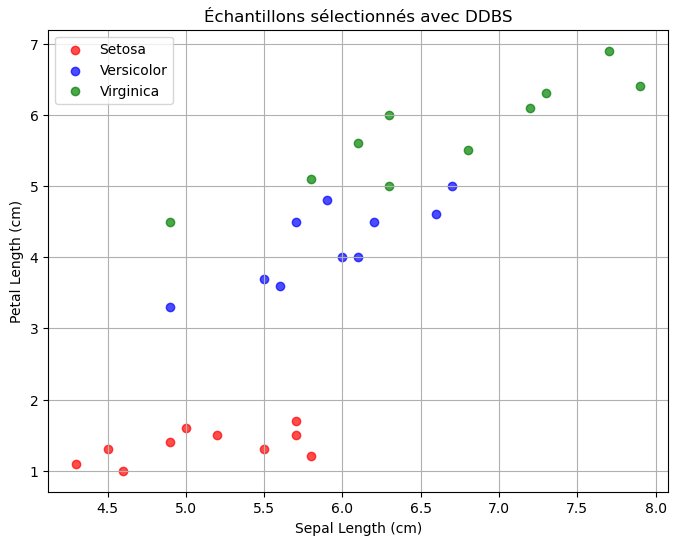

In [17]:
# Recharger les bibliothèques après la réinitialisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from scipy.spatial.distance import cdist

# Fonction pour charger le dataset Iris
def load_iris_dataset():
    """Charge le dataset Iris sous forme de DataFrame."""
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['species'] = iris.target  # Ajout des labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)
    return df

# Fonction pour calculer une distance (Manhattan ou Euclidienne)
def compute_distance(X, Y, metric="manhattan"):
    """Calcule la distance entre les matrices X et Y selon la métrique choisie."""
    if metric == "manhattan":
        return cdist(X, Y, metric='cityblock')  # Distance de Manhattan
    elif metric == "euclidean":
        return cdist(X, Y, metric='euclidean')  # Distance Euclidienne
    else:
        raise ValueError("Métrique non supportée. Choisissez 'manhattan' ou 'euclidean'.")

# Fonction de Diversified Distance-Based Sampling avec choix de distance et distribution
def diversified_distance_based_sampling(df, percentage_per_class, distance_metric="manhattan", distribution_type="binomial"):
    """
    Applique Diversified Distance-Based Sampling (DDBS) en sélectionnant un pourcentage équilibré d'échantillons par classe,
    avec un choix de métrique de distance et de distribution.

    Arguments :
    - df : DataFrame contenant les données.
    - percentage_per_class : Pourcentage d'échantillons à sélectionner par classe (ex: 0.2 pour 20%).
    - distance_metric : Type de distance à utiliser ("manhattan" ou "euclidean").
    - distribution_type : Type de distribution ("uniform", "binomial", "geometric").

    Retourne :
    - DataFrame échantillonné
    """
    np.random.seed()  # Fixer la graine pour reproductibilité
    
    features = df.iloc[:, :-1].values  # Séparer les caractéristiques (X)
    labels = df.iloc[:, -1].values     # Séparer les étiquettes (y)
    
    sampled_indices = []  # Liste des indices sélectionnés
    candidate_indices = list(range(len(df)))  # Indices des candidats

    # Calculer le nombre d'échantillons à sélectionner par classe
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    samples_per_class = {cls: max(1, int(percentage_per_class * count)) for cls, count in zip(unique_classes, class_counts)}

    # Initialiser le comptage des classes sélectionnées
    class_selected_counts = {cls: 0 for cls in unique_classes}

    # Initialisation : Ajouter un premier point aléatoire de chaque classe
    for cls in unique_classes:
        cls_indices = [idx for idx in candidate_indices if labels[idx] == cls]
        first_sample = np.random.choice(cls_indices)
        sampled_indices.append(first_sample)
        candidate_indices.remove(first_sample)
        class_selected_counts[cls] += 1

    # Continuer à sélectionner tant qu'au moins une classe n'a pas atteint son quota
    while any(class_selected_counts[cls] < samples_per_class[cls] for cls in unique_classes):
        # Filtrer les classes ayant déjà atteint leur quota
        remaining_classes = [cls for cls in unique_classes if class_selected_counts[cls] < samples_per_class[cls]]

        if not remaining_classes:
            break  # Si toutes les classes ont atteint leur quota, on arrête

        # Calculer la distance selon la métrique choisie
        sampled_features = features[sampled_indices]
        candidate_features = features[candidate_indices]
        distances = compute_distance(sampled_features, candidate_features, metric=distance_metric)

        # Déterminer la distance maximale actuelle
        max_distance = distances.max()

        # Sélectionner une distance selon la distribution choisie
        if distribution_type == "uniform":
            selected_distance = np.random.randint(1, max_distance + 1)
        elif distribution_type == "binomial":
            selected_distance = np.random.binomial(n=max_distance, p=0.5)
        elif distribution_type == "geometric":
            selected_distance = min(max_distance, np.random.geometric(0.3))
        else:
            raise ValueError("Distribution non supportée. Choisissez 'uniform', 'binomial', ou 'geometric'.")

        # Sélectionner le candidat avec une distance minimale respectant le seuil
        best_candidate = None
        best_candidate_class = None
        min_distances = distances.min(axis=0)

        for idx, candidate_idx in enumerate(candidate_indices):
            candidate_class = labels[candidate_idx]
            if candidate_class in remaining_classes:
                if min_distances[idx] >= selected_distance:
                    best_candidate = candidate_idx
                    best_candidate_class = candidate_class
                    break

        # Si aucun candidat ne respecte la contrainte, prendre celui avec la distance maximale restante
        if best_candidate is None:
            remaining_indices = [i for i, idx in enumerate(candidate_indices) if labels[idx] in remaining_classes]
            if remaining_indices:
                best_candidate_idx = remaining_indices[np.argmax(np.take(min_distances, remaining_indices))]
                best_candidate = candidate_indices[best_candidate_idx]
                best_candidate_class = labels[best_candidate]

        # Ajouter le candidat à l'échantillon
        sampled_indices.append(best_candidate)
        candidate_indices.remove(best_candidate)
        class_selected_counts[best_candidate_class] += 1

    return df.iloc[sampled_indices]  # Retourne le sous-ensemble sélectionné

# Charger le dataset Iris
df_iris = load_iris_dataset()

# Définir le pourcentage d'échantillons à sélectionner par classe (20% par classe)
percentage_per_class = 0.2

# Choisir la métrique de distance et la distribution
distance_choice = "euclidean"  # Peut être "manhattan" ou "euclidean"
distribution_choice = "geometric"  # Peut être "uniform", "binomial", ou "geometric"

# Appliquer la version DDBS avec la distance et la distribution choisies
sampled_iris = diversified_distance_based_sampling(df_iris, percentage_per_class, distance_choice, distribution_choice)

# Extraire les caractéristiques pour le graphique
selected_features = sampled_iris.iloc[:, [0, 2]].values  # Utiliser "sepal length" et "petal length"
selected_labels = sampled_iris.iloc[:, -1].values  # Espèces sélectionnées

# Afficher les points sélectionnés sur un graphe
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
labels_map = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

for cls in np.unique(selected_labels):
    class_indices = selected_labels == cls
    plt.scatter(selected_features[class_indices, 0], selected_features[class_indices, 1],
                color=colors[int(cls)], label=labels_map[cls], alpha=0.7)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Échantillons sélectionnés avec DDBS")
plt.legend()
plt.grid(True)
plt.show()
